# print ready
We use 1x1 smooth lego pieces on a 32x32 base plate as a relief print matrix. Here we use methods from `PixelfyOps` to create and visualise print patterns.

In [1]:
from PIL import Image
from collections import Counter
import math
from matplotlib import colors as mcolors

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name
    
def fig_seperated_colors(img, scaling=10):
    channels = separate_colors(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*4,6))
    axs[0] = ax_gridded_imshow(axs[0], img)
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))

        ax = ax_gridded_imshow(ax, img)
        ax.set_title(nearest_css4_color_name(color))
    return fig, axs

def ax_gridded_imshow(ax, img, scaling=10):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling*5 for i in range(int( width/5)+1)]: ax.axvline(v)
    for h in [i*scaling*5 for i in range(int(height/5)+1)]: ax.axhline(h)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))

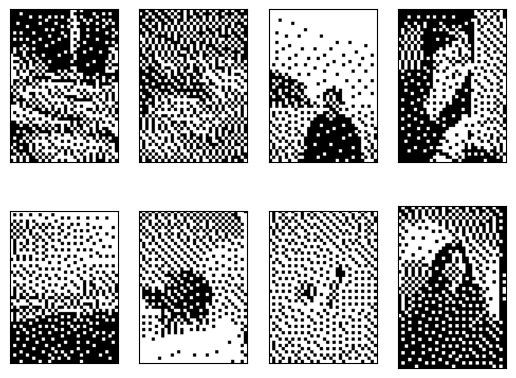

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 
    
directory = '../img/photo'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.jpg')])
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([])
    ax.set_yticks([])

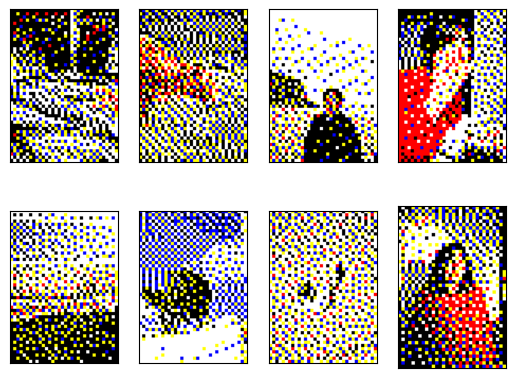

In [3]:
palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([])
    ax.set_yticks([])

In [4]:
palette = [(0,0,0)]
for i in range(5):
    palette.append((int(255/(i+1)),int(255/(i+1)),int(255/(i+1))))
palette

[(0, 0, 0),
 (255, 255, 255),
 (127, 127, 127),
 (85, 85, 85),
 (63, 63, 63),
 (51, 51, 51)]

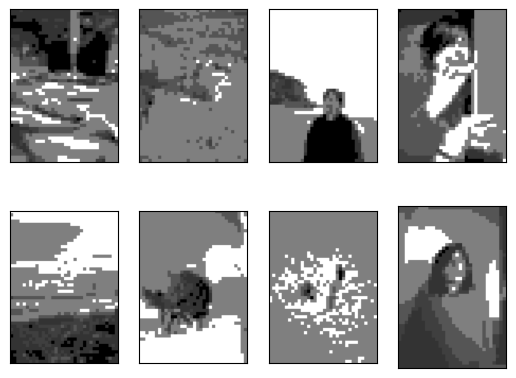

In [5]:
# palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.4)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([])
    ax.set_yticks([])

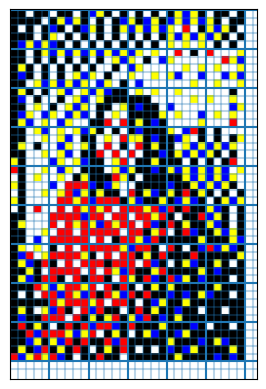

In [6]:
def ax_gridded_imshow(ax, img, scaling=10):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling*5 for i in range(int( width/5)+1)]: ax.axvline(v)
    for h in [i*scaling*5 for i in range(int(height/5)+1)]: ax.axhline(h)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]
img = Image.open(files[-1])
px = Pixelfy(img, upscaling=1, resolution=(45,45), dithering=0.6)
px.set_palette(palette)
img = px.make()

fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

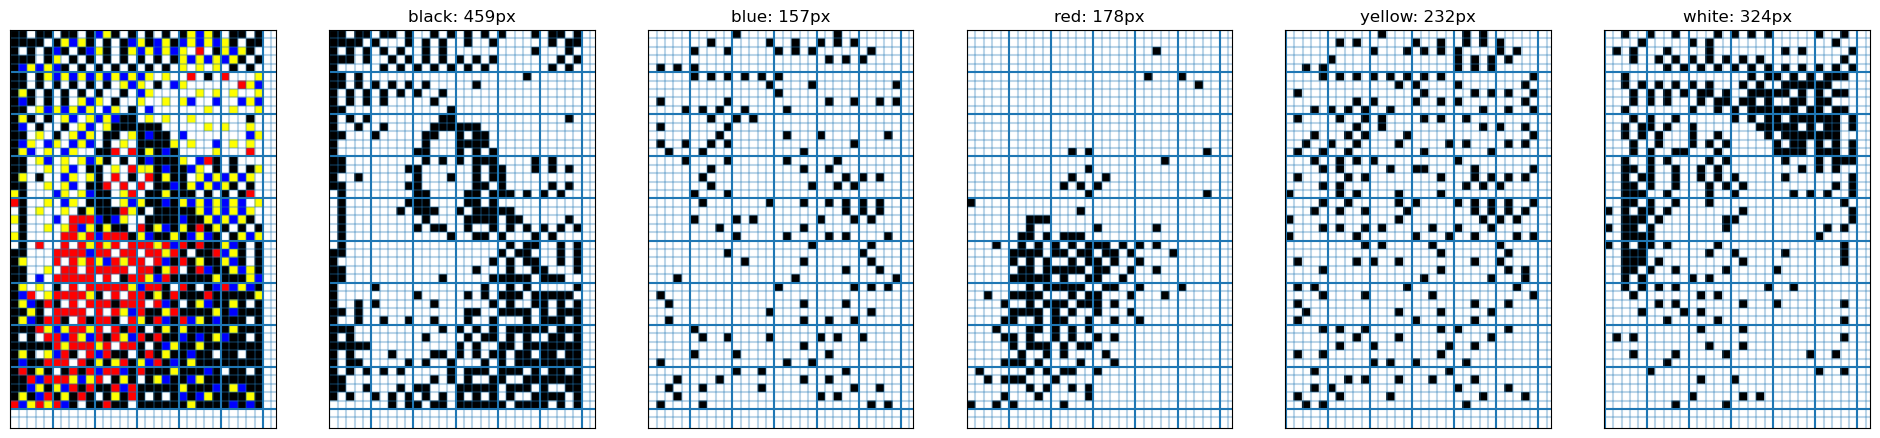

In [7]:
from PIL import Image
import math
from matplotlib import colors as mcolors

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name
    
def fig_seperated_colors(img, scaling=10):
    channels = separate_colors(img)
    count = color_histogram(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*4,6))
    axs[0] = ax_gridded_imshow(axs[0], img)
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))

        ax = ax_gridded_imshow(ax, img)
        ax.set_title(f'{nearest_css4_color_name(color)}: {(count[color])}px')
    return fig, axs
    
img = Image.open(files[-1])
px = Pixelfy(img, upscaling=1, resolution=(45,45), dithering=0.6)
px.set_palette(palette)
img = px.make()

fig = fig_seperated_colors(img)

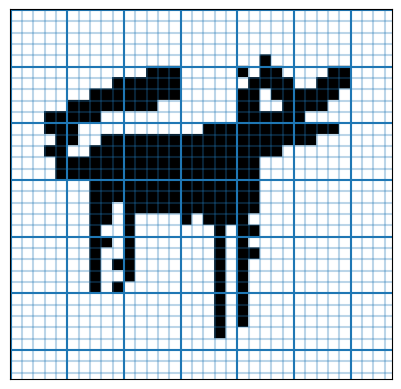

In [8]:
f =  '../img/drawing/dogo.png'
palette = [(0,0,0), (255,255,255)]

im = Image.open(f).convert("RGB")
px = Pixelfy(im, upscaling=1, resolution=(32,32), dithering=0.6)
px.set_palette(palette)
img = px.make()


fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

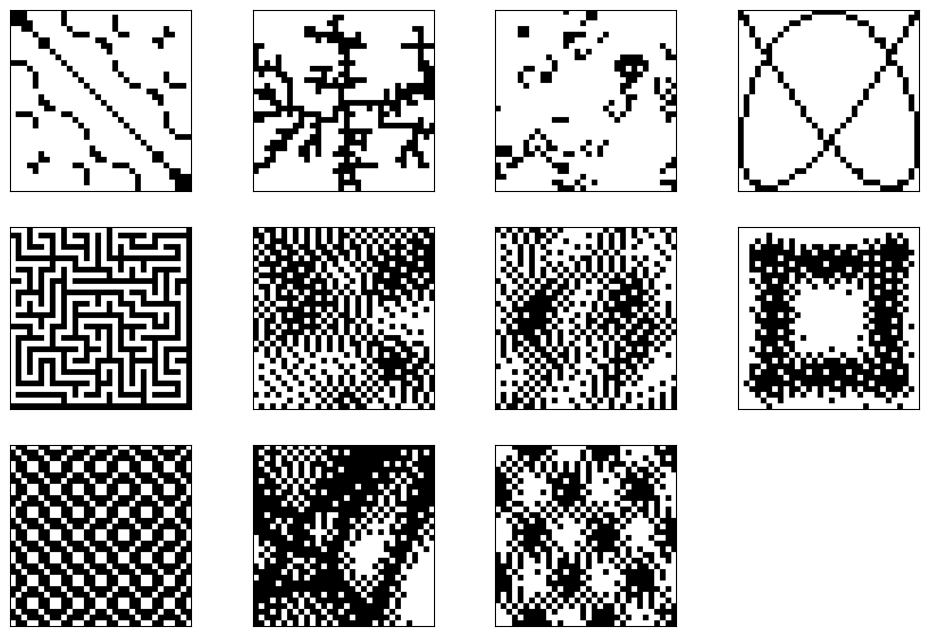

In [9]:
import pattern 
import inspect

seed = 187
palette = [(0,0,0),(255,255,255)]
generators = [obj for name, obj in inspect.getmembers(pattern, inspect.isclass)
              if name.endswith('Generator') and name != 'Generator']


fig, axs = plt.subplots(3,4, figsize=(12,8))
axs = axs.ravel()

for gen, ax in zip(generators, axs):
    try:
        img = gen(seed=seed).generate()
    except TypeError:
        img = gen().generate()
    
    img = img.convert("RGB")
    img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)
    img = img.resize((320, 320), Image.NEAREST)
    
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

fig.delaxes(axs[-1])


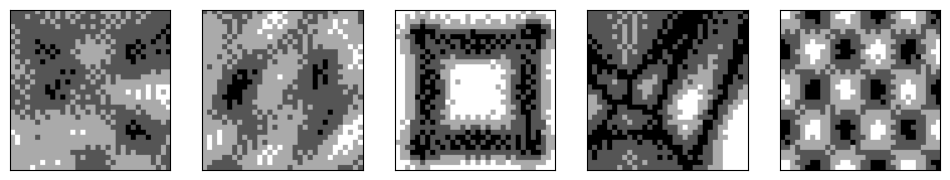

In [10]:
palette = [(0,0,0), (127, 127, 127), (255,255,255)]
palette = [(0,0,0), (85, 85, 85), (170, 170, 170), (255,255,255)]

generators = [
    pattern.NoiseGenerator, 
    pattern.PlasmaGenerator, 
    pattern.ReactionDiffusionGenerator, 
    pattern.VoronoiGenerator, 
    pattern.WaveGenerator]

fig, axs = plt.subplots(1,5, figsize=(12,8))
for gen, ax in zip(generators, axs):
    try:
        img = gen(seed=seed).generate()
    except TypeError:
        img = gen().generate()
    
    img = img.convert("RGB")
    img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)
    img = img.resize((320, 320), Image.NEAREST)
    
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

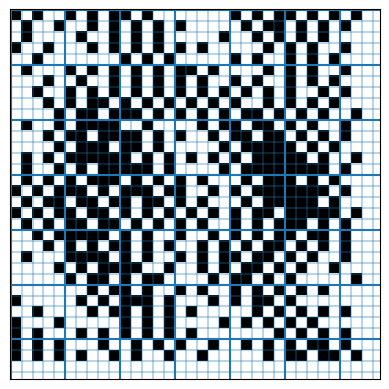

In [11]:
palette = [(0,0,0), (255,255,255)]
img = pattern.PlasmaGenerator(seed=seed).generate()
img = img.convert("RGB")
img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)

fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

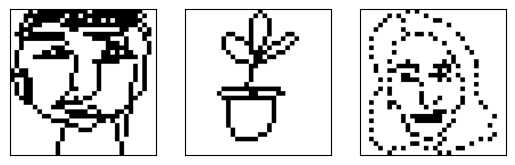

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 

directory = '../img/drawing'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.jpg')])
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(1,len(files))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    im = px.make()
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])

In [13]:
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])
files

['../img/drawing/dogo.png',
 '../img/drawing/h00.png',
 '../img/drawing/h01.png',
 '../img/drawing/h03.png',
 '../img/drawing/h04.png',
 '../img/drawing/ini07.png',
 '../img/drawing/pixil-frame-0 (10).png',
 '../img/drawing/pixil-frame-0 (12).png',
 '../img/drawing/pixil-frame-0 (8).png',
 '../img/drawing/pixil-frame-0 (9).png']

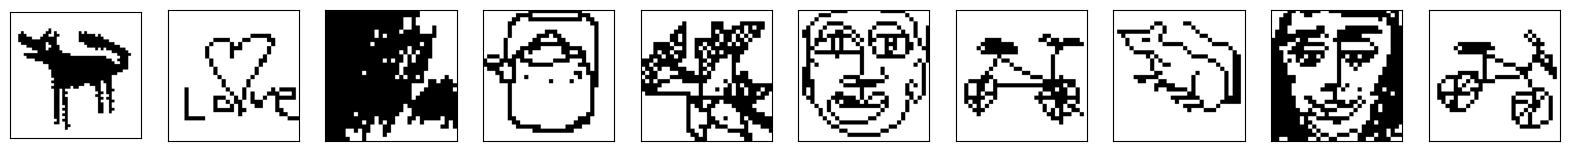

In [14]:
directory = '../img/drawing'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    im = Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im.convert('RGBA')).convert('RGB')
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    im = px.make()
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])

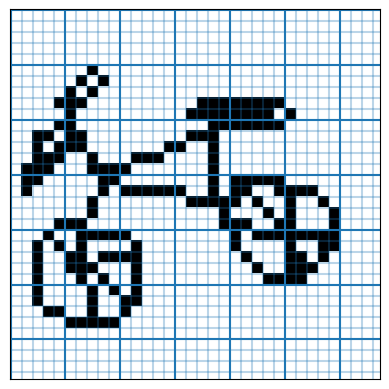

In [15]:
palette = [(0,0,0), (255,255,255)]
img = Image.open(f)
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
img = img.convert("RGB")
img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)

fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

In [16]:
from collections import Counter
from PIL import Image

def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))

for f in files[-2::]:
    palette = [(0,0,0), (255,255,255)]
    img = Image.open(f)
    img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
    img = img.convert("RGB")
    img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)
    print(color_histogram(img))

{(255, 255, 255): 467, (0, 0, 0): 557}
{(255, 255, 255): 843, (0, 0, 0): 181}


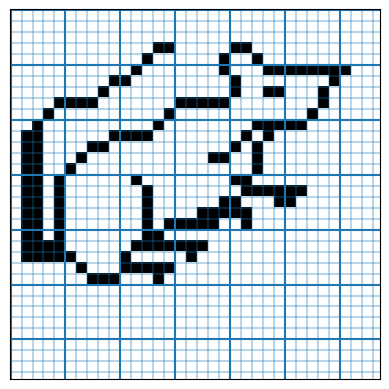

In [17]:
palette = [(0,0,0), (255,255,255)]
img = Image.open(files[-3])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
img = img.convert("RGB")
img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)


fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

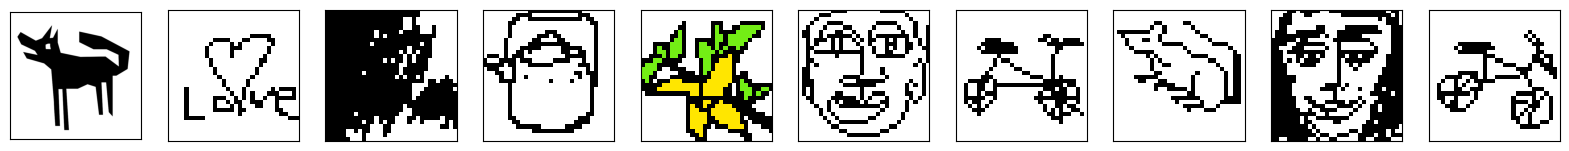

In [18]:

palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]
# palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])

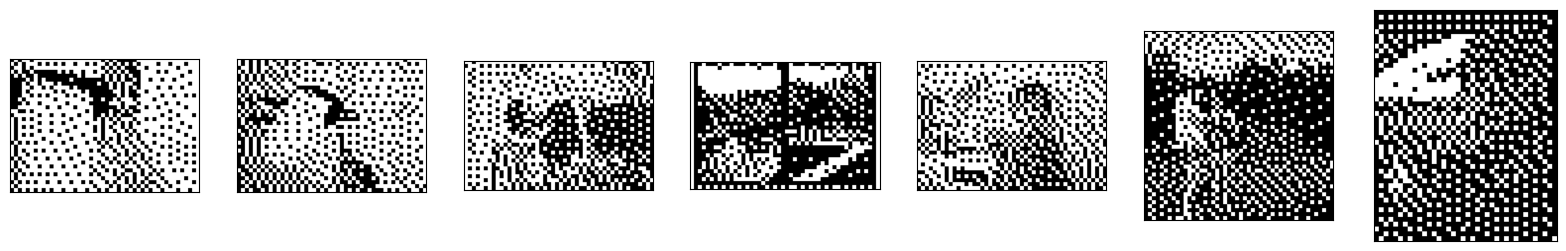

In [19]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 
    
directory = '../temp'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.upper().endswith('.JPG')])
palette = [(0,0,0), (255,255,255)]


fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([])
    ax.set_yticks([])

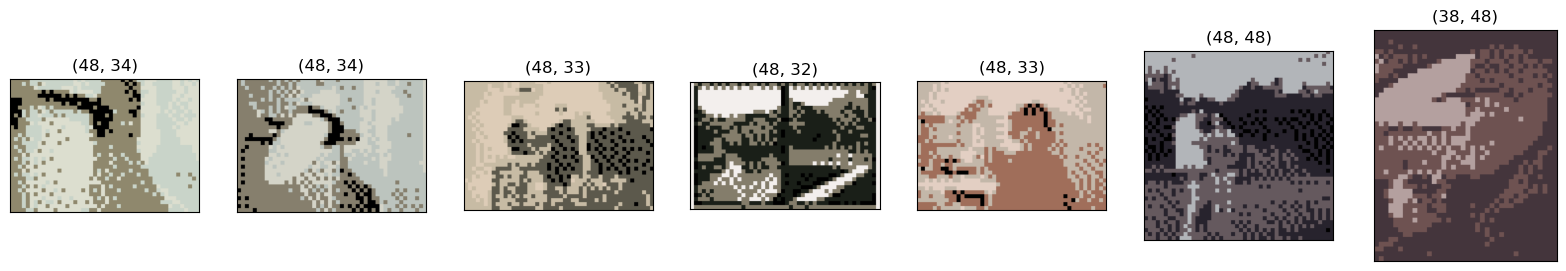

In [20]:
def greyscale_palette(n):
    palette = [(0,0,0)]
    for i in range(n):
        palette.append((int(255/(i+1)),int(255/(i+1)),int(255/(i+1))))
    return palette

palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]
palette = greyscale_palette(4)


fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    palette = PixelfyOps.infer_palette(im, ncolors=3)
    px = Pixelfy(im, upscaling=1, resolution=(48,48), dithering=0.9)
    px.set_palette(palette)
    im = px.make()
    ax.set_title(im.size)
    
    im = PixelfyOps.scale_up(im,10)
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])

(48, 34) {(143, 136, 109): 553, (201, 212, 201): 457, (220, 222, 207): 525, (0, 0, 0): 97}
(48, 34) {(134, 127, 109): 527, (188, 196, 190): 565, (212, 212, 200): 448, (0, 0, 0): 92}
(48, 33) {(199, 187, 164): 526, (221, 204, 183): 376, (92, 89, 76): 582, (0, 0, 0): 100}
(48, 32) {(243, 239, 237): 334, (132, 125, 107): 533, (26, 31, 24): 588, (0, 0, 0): 81}
(48, 33) {(195, 183, 169): 579, (227, 207, 195): 361, (160, 110, 90): 606, (0, 0, 0): 38}
(48, 48) {(178, 181, 185): 567, (101, 89, 94): 778, (39, 35, 45): 831, (0, 0, 0): 128}
(38, 48) {(68, 53, 60): 873, (110, 82, 81): 635, (180, 160, 159): 316}


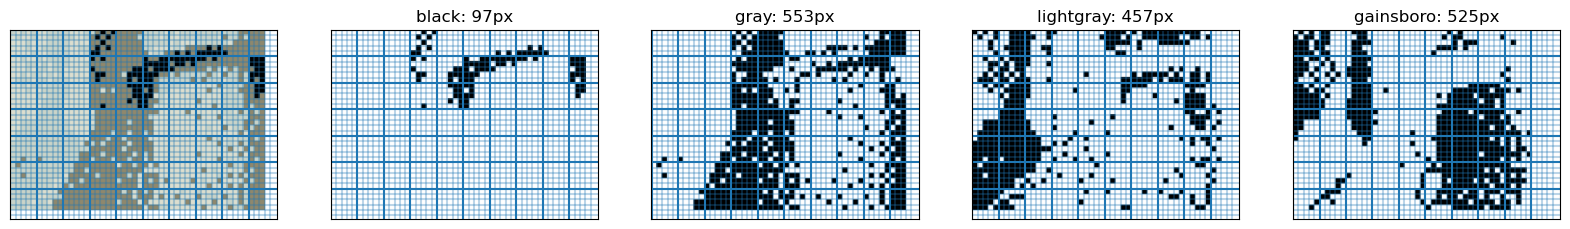

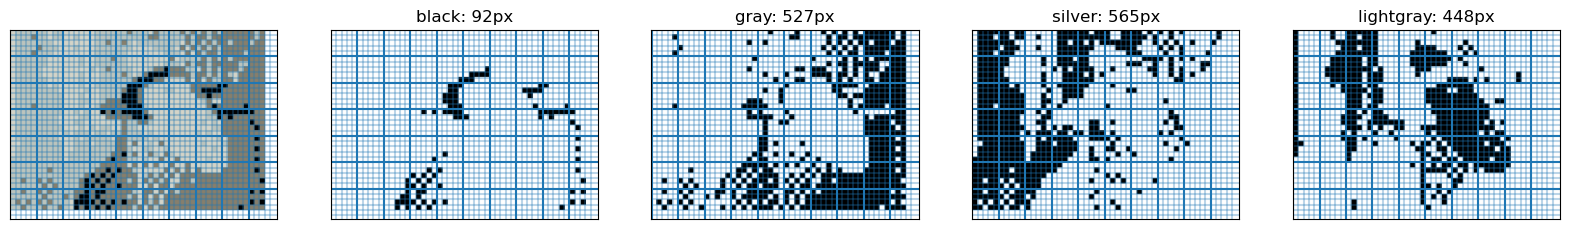

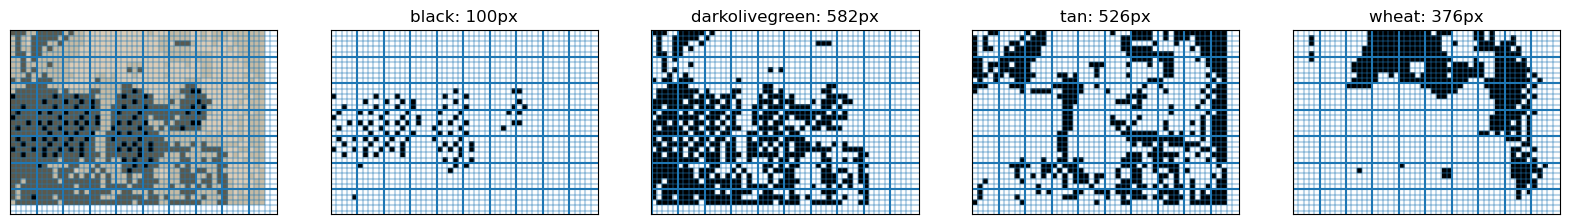

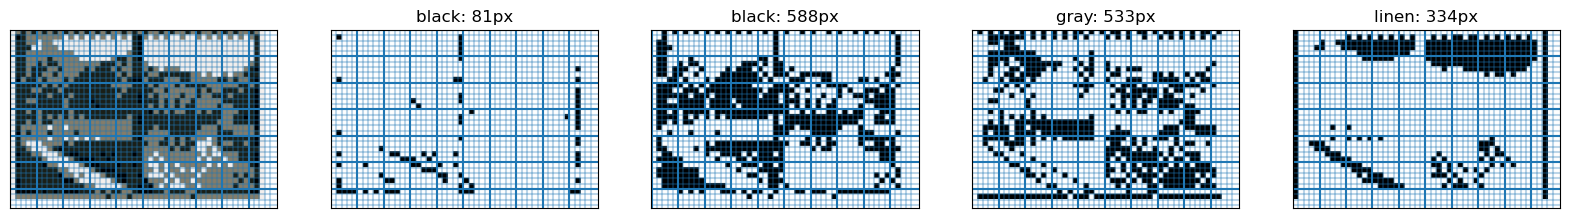

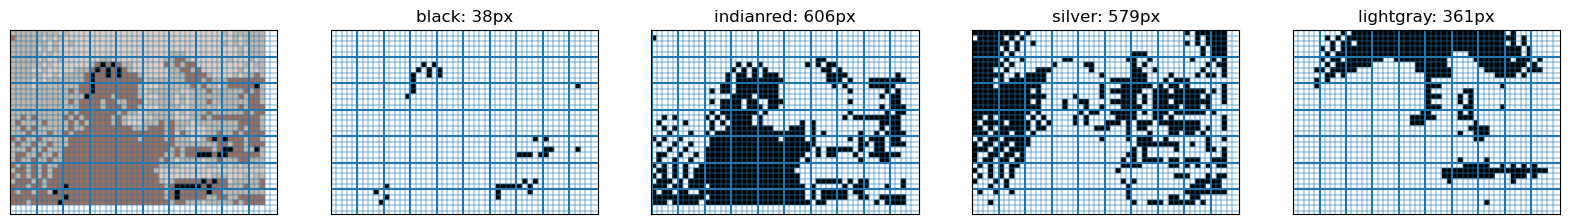

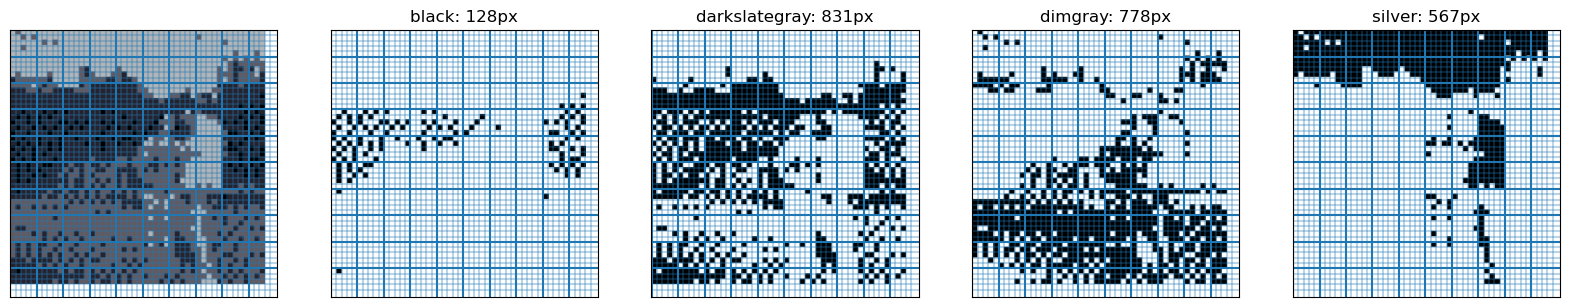

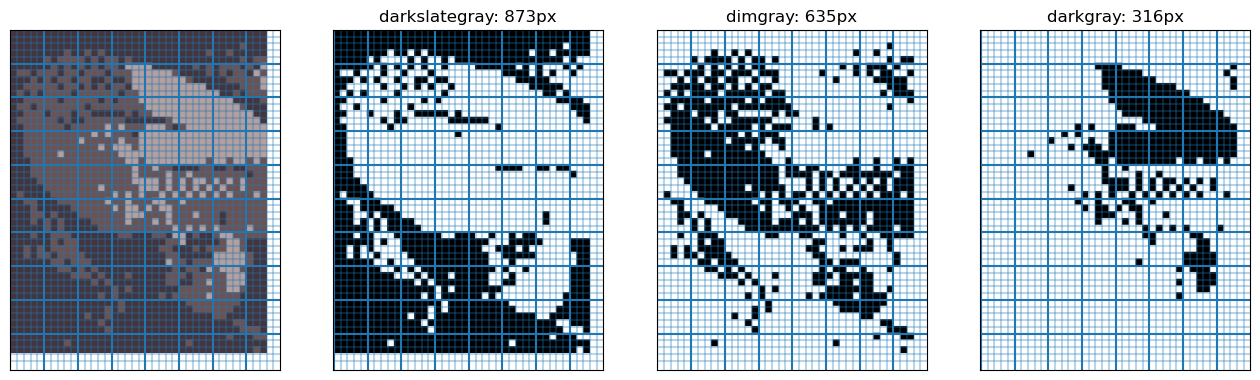

In [21]:
for f in files: 
    ofile = "../temp/pattern/" + os.path.basename(f)
    im = Image.open(f)
    palette = PixelfyOps.infer_palette(im, ncolors=3)
    px = Pixelfy(im, upscaling=1, resolution=(48,48), dithering=0.9)
    px.set_palette(palette)
    im = px.make()
    print(im.size, color_histogram(im))
    fig, axs = fig_seperated_colors(im)
    fig.savefig(ofile)

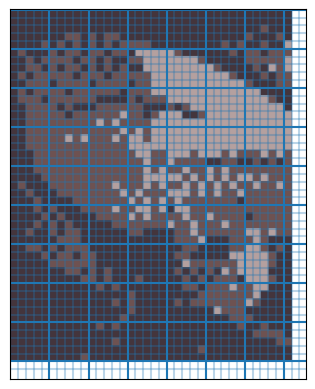

In [22]:

img = Image.open(files[-1])
px = Pixelfy(img, upscaling=1, resolution=(45,45), dithering=0.6)
px.set_palette(palette)
img = px.make()

fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

## Utility functions from this script:

In [23]:
from PIL import Image
from collections import Counter
import math
from matplotlib import colors as mcolors

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name
    
def fig_seperated_colors(img, scaling=10):
    channels = separate_colors(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*4,6))
    axs[0] = ax_gridded_imshow(axs[0], img)
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))

        ax = ax_gridded_imshow(ax, img)
        ax.set_title(nearest_css4_color_name(color))
    return fig, axs

def ax_gridded_imshow(ax, img, scaling=10):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling*5 for i in range(int( width/5)+1)]: ax.axvline(v)
    for h in [i*scaling*5 for i in range(int(height/5)+1)]: ax.axhline(h)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))